# **Predict Students' Dropout and Academic Success**
## Project Overview
This project aims to develop an early warning system to predict whether a student will dropout, enroll, or graduate based on various demographic, socio-economic, and academic performance factors. 
By employing a **Timeline-Based Machine Learning Approach**, we can understand the key factors contributing to student attrition and help institutions intervene early.

## Table of Contents
1. **Data Exploration & Visualization (EDA)**
2. **Feature Engineering**
3. **Model Training & Timeline Evaluation**
4. **Advanced Machine Learning & Deployment Preparation**


# Proportion of overall student status
From all data There are approximately 2,209 students who graduated, 1,421 dropped out, and 794 are still studying. The proportion of people who dropped out is considered quite high (approximately 32%).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("Predict Students' Dropout and Academic Success.csv")

# Proportion of overall student status
print("Proportion of student status")
target_counts = df['Target'].value_counts()
print(target_counts)
print(f"Dropout proportion: {(target_counts['Dropout'] / len(df)) * 100:.2f}%\n")

Proportion of student status
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Dropout proportion: 32.12%



# Early warning signs from first semester academic performance
According to the 1st Semester Approved Units graph, there is a stark contrast between student groups. Graduates consistently demonstrate high performance, with the majority successfully completing most of their first-term credits. Conversely, Dropouts tend to pass significantly fewer units, with many failing to complete any courses at all during their initial semester.

C:\Users\COLORFUL\AppData\Local\Temp\ipykernel_16308\2339265227.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


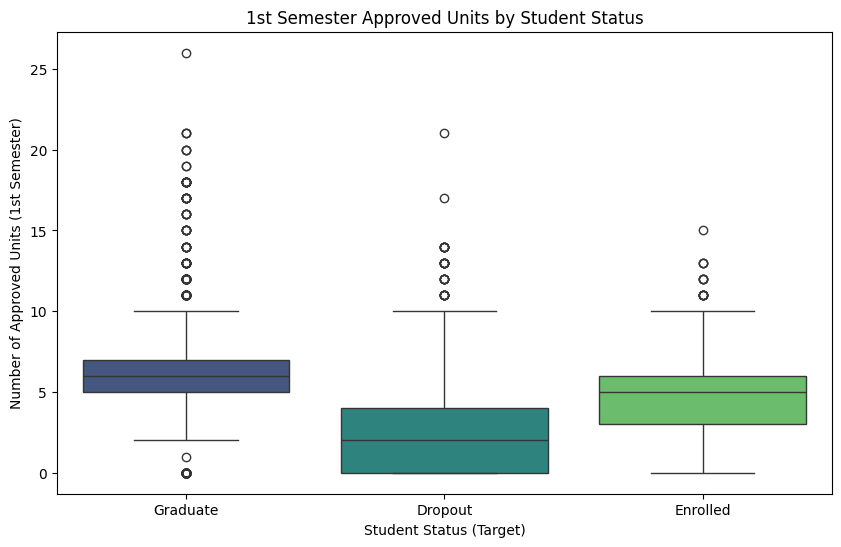

In [2]:
# Early warning signs from first semester academic performance
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Target',
    y='Curricular units 1st sem (approved)',
    order=['Graduate', 'Dropout', 'Enrolled'],
    palette='viridis'
)
plt.title('1st Semester Approved Units by Student Status')
plt.xlabel('Student Status (Target)')
plt.ylabel('Number of Approved Units (1st Semester)')
plt.show()

# Financial factors have a huge impact on studies.
From the graph (Tuition Fees Up to Date), if we look at the status of tuition payments Very interesting relationships will be found:
Students who "pay their tuition on time (Yes)" are more likely to graduate.
On the other hand, students who "pay tuition fees (No)" have a significantly higher proportion of dropping out (Dropout) than those who graduate.

<Figure size 800x500 with 0 Axes>

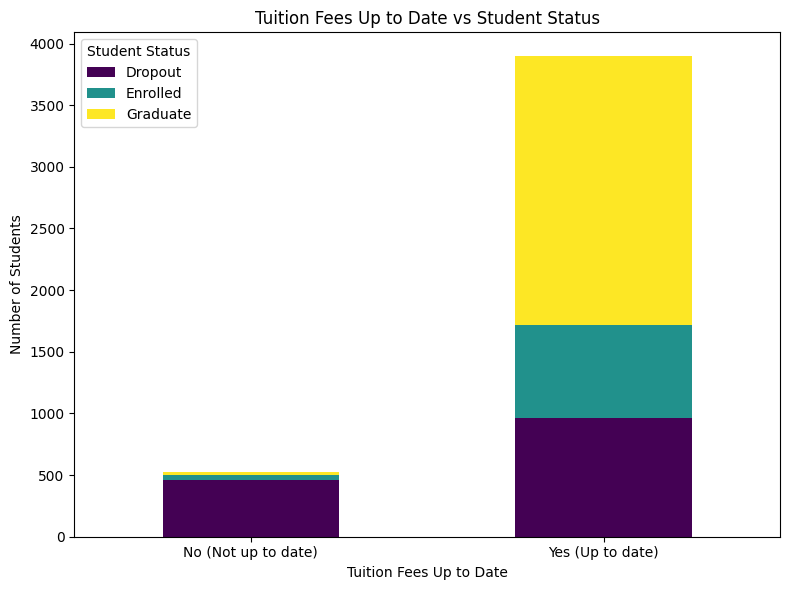

In [3]:
# Financial factors have a huge impact on studies.
plt.figure(figsize=(8, 5))
# Count the number of students, grouped by 'Payment of tuition' and 'Status'
fee_data = df.groupby(['Tuition fees up to date', 'Target']).size().unstack()

# Change the name of Index to make it easier to understand (0 = No, 1 = Yes)
fee_data.index = ['No (Not up to date)', 'Yes (Up to date)']

# Create a stacked bar chart (Stacked Bar Chart)
fee_data.plot(kind='bar', stacked=True, colormap='viridis', figsize=(8, 6))
plt.title('Tuition Fees Up to Date vs Student Status')
plt.xlabel('Tuition Fees Up to Date')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.legend(title='Student Status')
plt.tight_layout()
plt.show()

# Student debt (Debtor)
The data clearly indicates that students who Have outstanding debts with the university There is a very high resignation rate of approximately 62%, while people without debt have only a 28% chance of quitting.

**Importance:** This is the point where it can be said that financial problems are the top factor. that pushes students to drop out of school

High school dropout rate vs. debt
Target        Dropout  Enrolled  Graduate
No Debt (0)     28.28     17.95     53.76
Has Debt (1)    62.03     17.89     20.08


<Figure size 800x500 with 0 Axes>

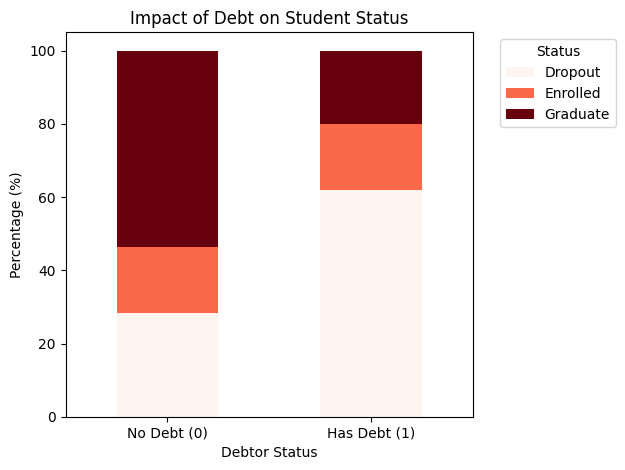

In [4]:
# Student debt (Debtor)
print("High school dropout rate vs. debt")
debtor_stat = df.groupby('Debtor')['Target'].value_counts(normalize=True).unstack() * 100
debtor_stat.index = ['No Debt (0)', 'Has Debt (1)']
print(debtor_stat.round(2))


plt.figure(figsize=(8, 5))
debtor_stat.plot(kind='bar', stacked=True, colormap='Reds')
plt.title('Impact of Debt on Student Status')
plt.xlabel('Debtor Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Receiving a scholarship (Scholarship holder)
Having a scholarship Greatly reduces the turnover rate! Students with scholarships have only a 12% chance of dropping out, while those without scholarships have a nearly 40% chance of dropping out.

**Importance:** It is statistically confirmed that "Scholarships really help students to complete their studies."

Dropout rate vs. scholarship receipt
Target               Dropout  Enrolled  Graduate
No Scholarship (0)     38.71     19.97     41.32
Has Scholarship (1)    12.19     11.83     75.98


<Figure size 800x500 with 0 Axes>

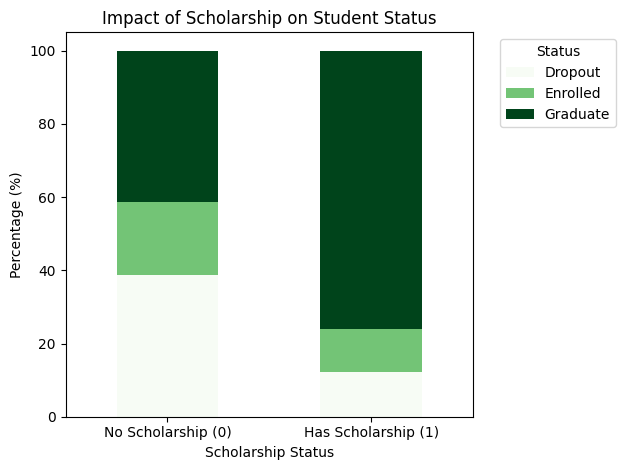

In [5]:
# Receiving a scholarship (Scholarship holder)
print("Dropout rate vs. scholarship receipt")
schol_stat = df.groupby('Scholarship holder')['Target'].value_counts(normalize=True).unstack() * 100
schol_stat.index = ['No Scholarship (0)', 'Has Scholarship (1)']
print(schol_stat.round(2))

plt.figure(figsize=(8, 5))
schol_stat.plot(kind='bar', stacked=True, colormap='Greens')
plt.title('Impact of Scholarship on Student Status')
plt.xlabel('Scholarship Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Gender gap in graduation
From the data, it was interestingly found that male students have a high resignation rate of 45%, which is higher than female students. with a resignation rate of only 25%, almost double!

**Importance:** What happened to the male students? Why are they more likely to not graduate? It may have to do with having to go to work to earn money. or lifestyle behavior

High school dropout rate vs. gender
Target      Dropout  Enrolled  Graduate
Female (0)    25.10     16.98     57.91
Male (1)      45.05     19.73     35.22


<Figure size 800x500 with 0 Axes>

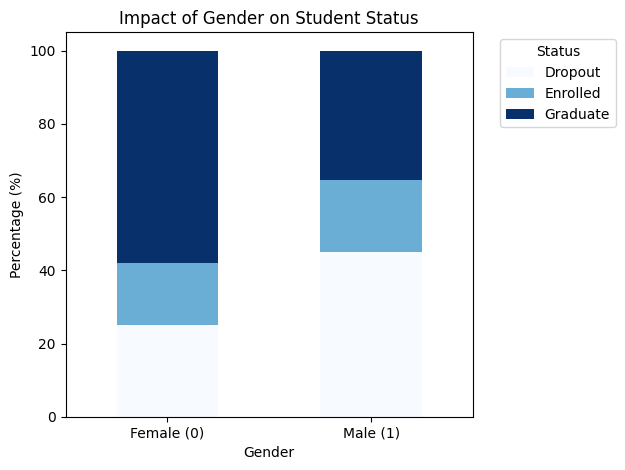

In [6]:
# Gender
print("High school dropout rate vs. gender")
gender_stat = df.groupby('Gender')['Target'].value_counts(normalize=True).unstack() * 100
# Based on metadata: 0 = female, 1 = male
gender_stat.index = ['Female (0)', 'Male (1)']
print(gender_stat.round(2))

plt.figure(figsize=(8, 5))
gender_stat.plot(kind='bar', stacked=True, colormap='Blues')
plt.title('Impact of Gender on Student Status')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Age at enrollment
If you create a Boxplot graph, look at the age distribution. It is found that students who are in the Dropout group tend to have a higher average age when they enter school than those who graduate.

**Important:** Students who enter school at an older age are often adults who work or have families (Adult learners), causing them to have more burdens and time pressures.

Average age at entry into school separated by status
Target
Dropout     26.07
Enrolled    22.37
Graduate    21.78
Name: Age at enrollment, dtype: float64


C:\Users\COLORFUL\AppData\Local\Temp\ipykernel_16308\2927843720.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


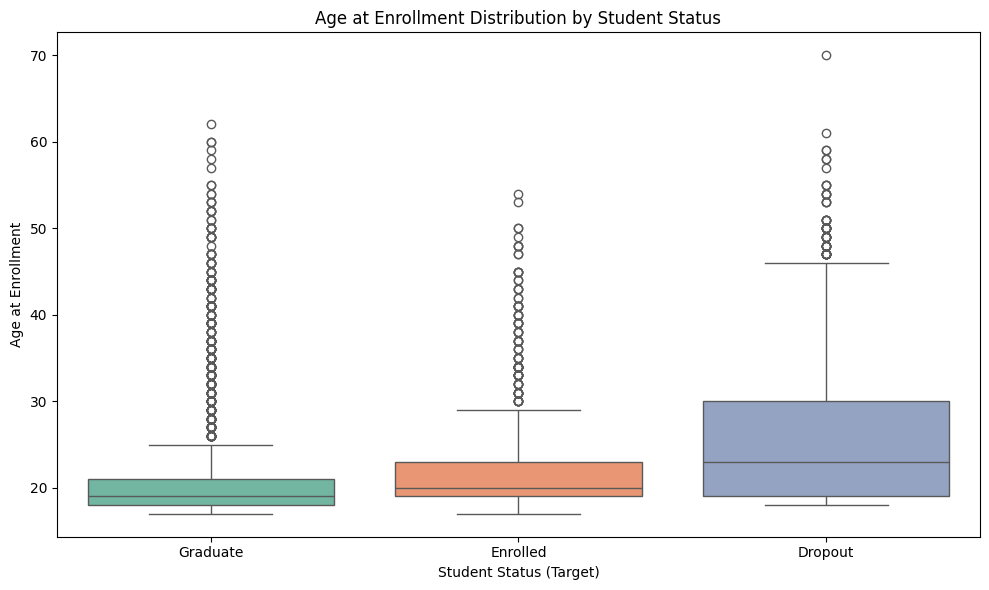

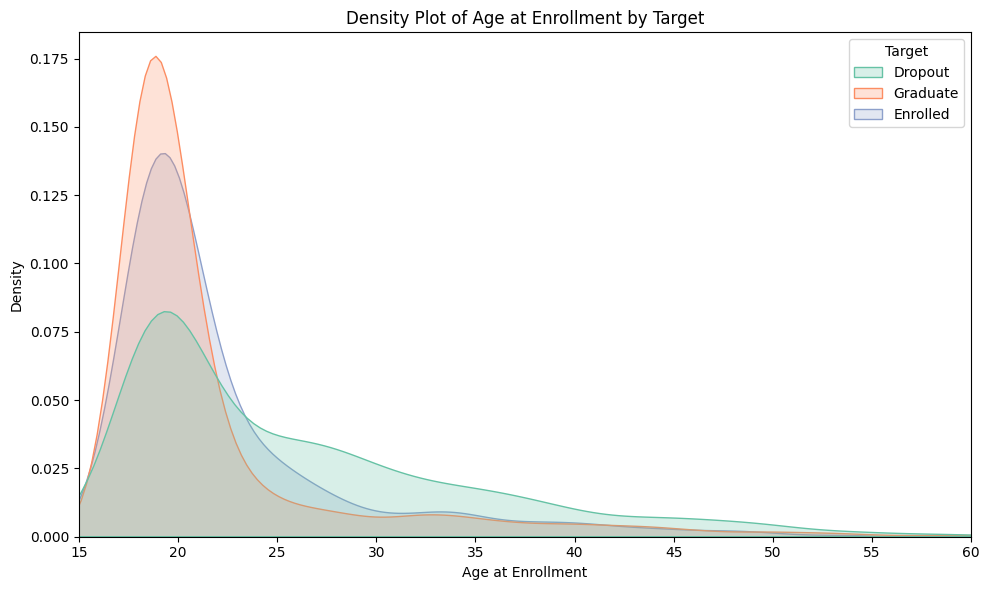

In [7]:
# Age at enrollment
print("Average age at entry into school separated by status")
age_stat = df.groupby('Target')['Age at enrollment'].mean()
print(age_stat.round(2))

# Create a Boxplot graph to see the distribution of ages in each group.
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Target',
    y='Age at enrollment',
    order=['Graduate', 'Enrolled', 'Dropout'],
    palette='Set2'
)
plt.title('Age at Enrollment Distribution by Student Status')
plt.xlabel('Student Status (Target)')
plt.ylabel('Age at Enrollment')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Age at enrollment', hue='Target', fill=True, common_norm=False, palette='Set2')
plt.title('Density Plot of Age at Enrollment by Target')
plt.xlabel('Age at Enrollment')
plt.xlim(15, 60)
plt.tight_layout()
plt.show()

# **RandomForestClassifier**
# Summary of key findings from the project (Key Discoveries & Insights)
**Phase 1 (Day-1):** Although there is no university grade information yet, (Using the first day of surrender) the model was able to predict with 77% accuracy who would survive and who would resign. The analysis was based on age, high school grade, and initial tuition payment status.

**Phase 2 (End of Sem 1):** When students finish semester 1 and bring their learning results to evaluate. The system's accuracy jumps to nearly 88%.

**Summary of recommendations for universities (Actionable Recommendations):** Universities do not need to wait for student academic performance to deteriorate to the point of irreversibility. But Day-1 data can be used to assess risk immediately. to allocate a budget "Emergency scholarships" or arranging a team of advisors (Counseling) to take care of students with financial problems and older students. From the first day I stepped into the university

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load data and prepare data
df = pd.read_csv("Predict Students' Dropout and Academic Success.csv")

# Filter only people who graduated (Graduate) and resigned (Dropout) to do Binary Classification.
df_model = df[df['Target'].isin(['Dropout', 'Graduate'])]
X = df_model.drop('Target', axis=1)
y = df_model['Target']

# Create a dataset based on "Timeline"
# Pull out the names of the columns that are semester 1 and semester 2 academic results.
sem1_features = [col for col in X.columns if '1st sem' in col]
sem2_features = [col for col in X.columns if '2nd sem' in col]

# Set of data 1 (Day 1): First day of entry (no university grades), semesters 1 and 2 omitted.
X_day1 = X.drop(columns=sem1_features + sem2_features)

# Data set 2 (End of Sem 1): End of Semester 1 (only Semester 1 grades included), Semester 2 omitted.
X_sem1 = X.drop(columns=sem2_features)

# Divide data for Train / Test (use Random State 42 )
y_binary = y.map({'Dropout': 0, 'Graduate': 1}) # Convert Target to 0, 1 for easy measurement.
X_train_d1, X_test_d1, y_train, y_test = train_test_split(X_day1, y_binary, test_size=0.2, random_state=42)
X_train_s1, X_test_s1, _, _ = train_test_split(X_sem1, y_binary, test_size=0.2, random_state=42)

# Model training (Random Forest)
# create function
def train_and_evaluate(X_train, X_test, y_train, y_test, title):
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"{title}")
    print(f"Accuracy: {acc*100:.2f}%")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Dropout', 'Graduate']))
    return rf


Run the model comparing 2 time periods.

In [9]:
# Run the model comparing 2 time periods.
model_day1 = train_and_evaluate(X_train_d1, X_test_d1, y_train, y_test, "Model 1: Day-1 Prediction (No University Grades)")
print("\n" + "-"*54 + "\n")
model_sem1 = train_and_evaluate(X_train_s1, X_test_s1, y_train, y_test, "Model 2: End of Semester 1 Prediction")

Model 1: Day-1 Prediction (No University Grades)
Accuracy: 77.27%
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.73      0.64      0.68       277
    Graduate       0.79      0.86      0.82       449

    accuracy                           0.77       726
   macro avg       0.76      0.75      0.75       726
weighted avg       0.77      0.77      0.77       726


------------------------------------------------------

Model 2: End of Semester 1 Prediction
Accuracy: 87.74%
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.90      0.76      0.83       277
    Graduate       0.87      0.95      0.91       449

    accuracy                           0.88       726
   macro avg       0.88      0.86      0.87       726
weighted avg       0.88      0.88      0.88       726



C:\Users\COLORFUL\AppData\Local\Temp\ipykernel_16308\3076439625.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='magma')


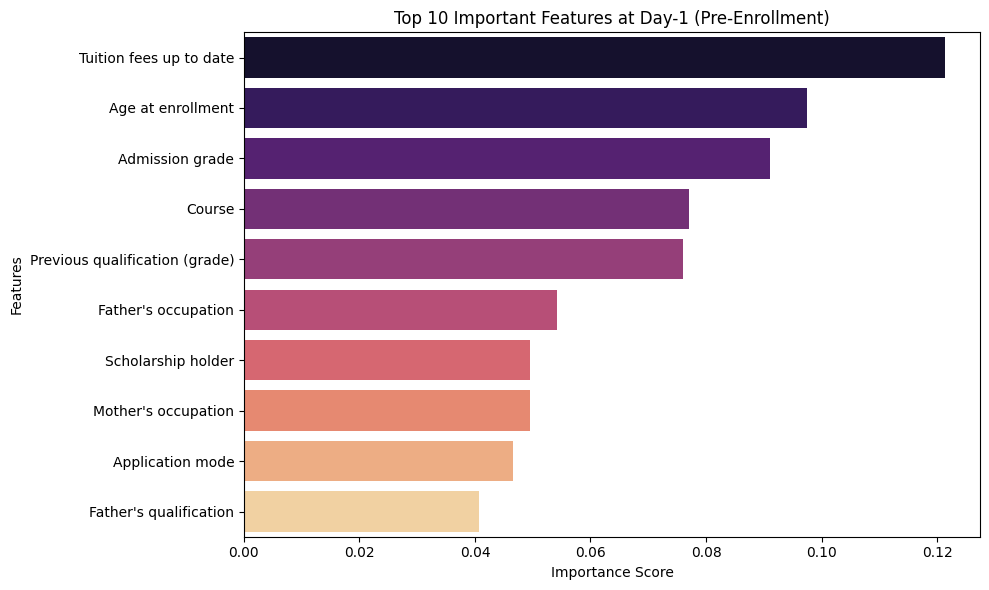

In [10]:
# Look at the Feature Importance of the Day-1 model. What made it launch from day one?
importances = pd.DataFrame({
    'Feature': X_day1.columns,
    'Importance': model_day1.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Important Features at Day-1 (Pre-Enrollment)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# **4. Advanced Machine Learning & Deployment Preparation**
## 4.1 Hyperparameter Tuning
To ensure our model achieves the best possible performance, we will perform Hyperparameter Tuning on the Day-1 model using `GridSearchCV`. This process searches for the optimal combination of parameters for the Random Forest Classifier.


In [11]:
from sklearn.model_selection import GridSearchCV
import joblib

print("Starting Hyperparameter Tuning for Day-1 Random Forest...")

# Defining parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Base model
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# GridSearchCV setup (cv=3 for faster execution during demonstration)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, scoring='accuracy', verbose=1)

# Fit GridSearchCV 
grid_search.fit(X_train_d1, y_train)

# Best model
best_rf_day1 = grid_search.best_estimator_
print(f"\nBest Parameters Found: {grid_search.best_params_}")

# Evaluate best model
y_pred_tuned = best_rf_day1.predict(X_test_d1)
print(f"\nTuned Model Accuracy: {accuracy_score(y_test, y_pred_tuned)*100:.2f}%")
print("Classification Report (Tuned):")
print(classification_report(y_test, y_pred_tuned, target_names=['Dropout', 'Graduate']))


Starting Hyperparameter Tuning for Day-1 Random Forest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits



Best Parameters Found: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Tuned Model Accuracy: 76.17%
Classification Report (Tuned):
              precision    recall  f1-score   support

     Dropout       0.73      0.60      0.66       277
    Graduate       0.78      0.86      0.82       449

    accuracy                           0.76       726
   macro avg       0.75      0.73      0.74       726
weighted avg       0.76      0.76      0.76       726



## 4.2 Model Deployment Preparation
Now that we have an optimized model for Day-1 predictions, we can save it to disk. This serialized model (`predict_dropout_model.pkl`) can then be integrated into a web application or an internal dashboard for real-time predictions.


In [12]:
# Save the best trained model to disk
model_filename = 'predict_dropout_model.pkl'
joblib.dump(best_rf_day1, model_filename)

print(f"Model successfully saved to {model_filename}")
print("The model is now ready for deployment in a production environment!")


Model successfully saved to predict_dropout_model.pkl
The model is now ready for deployment in a production environment!
